 #  Knowledge Graphs and Semantic Technologies -- KG measures and clustering tutorial

### Kim Lichtenberg, 2727165¶

First, make sure you have networkx installed, here you can find the [documentation](https://networkx.org/documentation/stable/reference/index.html).


In [1]:
import owlready2
## Uncomment if you do not have networkx installed (you should have it installed from the RDFS tutorial)
#import sys
#!{sys.executable} -m pip install networkx

import pandas as pd
import rdflib
from networkx.algorithms.centrality import group_betweenness_centrality
from rdflib import Literal
from rdflib.namespace import DC, FOAF

import networkx as nx
from owlready2 import *

* Owlready2 * Warning: optimized Cython parser module 'owlready2_optimized' is not available, defaulting to slower Python implementation


In this tutorial, we will focus on how to characterise an ontology or knowledge graph.

Load the ontology, which you have previously created in the OWL tutorial (load the asserted owl file).

In [2]:
ontology = rdflib.Graph()
ontology.parse("data/my_music_ontology_inferred.owl")

<Graph identifier=N707d217f66ef4048bf7e56f1e228478e (<class 'rdflib.graph.Graph'>)>

##  1. Basic (ontology) measures

Let's first focus on calculating basic measures:
* number of classes
* number of properties
* number of individuals
* number of triples
* number of entities (classes, individuals, etc. anything that can be places in the subject position in a triple/axiom)

We start by counting the number of classes in the ontology. This can be done using a SPARQL query. We want to get the unique classes used in the ontology.

PREFIX owl: <http://www.w3.org/2002/07/owl#>

SELECT DISTINCT ?s

WHERE { ?s rdf:type owl:Class. FILTER isURI(?s) }

This query gives as all the classes that also have a definition in the ontology. However, this does not have to equal the number of classes actually used by individuals. Hence, you need to be very specific about what the number you are retrieving represents.

In [3]:
answer = list(ontology.query(
    'PREFIX owl: <http://www.w3.org/2002/07/owl#> SELECT DISTINCT ?s WHERE { ?s rdf:type owl:Class. FILTER isURI(?s) }'
))
print("Number of classes: {f}".format(f=len(answer)))
for r in answer:
    print(r)


Number of classes: 9
(rdflib.term.URIRef('http://test.org/myonto.owl#Person'),)
(rdflib.term.URIRef('http://test.org/myonto.owl#Artist'),)
(rdflib.term.URIRef('http://test.org/myonto.owl#Location'),)
(rdflib.term.URIRef('http://test.org/myonto.owl#Song'),)
(rdflib.term.URIRef('http://test.org/myonto.owl#Genre'),)
(rdflib.term.URIRef('http://test.org/myonto.owl#Member'),)
(rdflib.term.URIRef('http://test.org/myonto.owl#SoloArtist'),)
(rdflib.term.URIRef('http://test.org/myonto.owl#SubGenre'),)
(rdflib.term.URIRef('http://test.org/myonto.owl#CollaboratingArtist'),)


Even though we used a query, a lot of this information can also be retrieved with owlready2. For example, the number of classes can be retrieved with the function onto.classes(). It returns all classes in the ontology. We try it below.


In [4]:
onto_file = "../data/my_music_ontology_inferred.owl"
or_ontology = get_ontology(onto_file).load()
answer = list(or_ontology.classes())

print("Number of classes: {f}".format(f=len(answer)))
for r in answer:
    print(r)

Number of classes: 9
my_music_ontology_inferred.Artist
my_music_ontology_inferred.Song
my_music_ontology_inferred.Location
my_music_ontology_inferred.Genre
my_music_ontology_inferred.Person
my_music_ontology_inferred.Member
my_music_ontology_inferred.SoloArtist
my_music_ontology_inferred.SubGenre
my_music_ontology_inferred.CollaboratingArtist


In [5]:
ind = list(or_ontology.individuals())
print(len(ind))

13


### Exercise 1

Get the following metrics from the Hybrid Intelligence ontology, using queries and check your answer using owlready2 functions.

* number of properties
* number of individuals
* number of triples
* number of entities (classes, individuals, etc. anything that can be places in the subject position in a triple/axiom)

In [6]:
from rdflib import Graph

ont = Graph()
ont.parse("data/hi_ontology.ttl", format="turtle")

# Get the number of properties
ont_properties = """
PREFIX owl: <http://www.w3.org/2002/07/owl#>
SELECT (COUNT(DISTINCT ?prop) AS ?property) WHERE {
  { ?prop a owl:ObjectProperty . }
  UNION
  { ?prop a owl:DatatypeProperty . }
  UNION
  { ?prop a owl:AnnotationProperty . }
}
"""

num_properties = ont.query(ont_properties)
print(f'Number of properties: {int(list(num_properties)[0][0])}')

Number of properties: 13


In [7]:
# Get the number of individuals
ont_individuals = """
PREFIX owl: <http://www.w3.org/2002/07/owl#>
SELECT (COUNT(DISTINCT ?individual) AS ?individual) WHERE {
  ?individual a owl:NamedIndividual .
}
"""

num_individuals = ont.query(ont_individuals)
print(f'Number of individuals: {int(list(num_individuals)[0][0])}')

Number of individuals: 28


In [8]:
# Get the number of triples
ont_triples = """
PREFIX owl: <http://www.w3.org/2002/07/owl#>
SELECT (COUNT(*) AS ?triples)
WHERE {
  ?s ?p ?o .
}
"""

num_triples = ont.query(ont_triples)
print(f'Number of triples: {int(list(num_triples)[0][0])}')

Number of triples: 114


Check answers using `owlready2` function:

In [9]:
# Transform to .xml
ont = Graph()
ont.parse("data/hi_ontology.ttl")
ont.serialize(destination="data/hi_ontology.owl", format = "xml")

<Graph identifier=Na888f39677e44467ada40abcc71e7955 (<class 'rdflib.graph.Graph'>)>

In [10]:
onto_path = "../data/hi_ontology.owl"
onto = get_ontology(onto_path).load()

print(f'Base iri: {onto.base_iri}\n')
print(f'Number of classes: {len(list(onto.classes()))}\n Classes are: {list(onto.classes())}\n')
print(f'Number of properties: {len(list((onto.properties())))}\n Properties are: {list(onto.properties())}\n')
print(f'Number of individuals: {len(list((onto.individuals())))}\n Individuals are: {list(onto.individuals())}\n')

# Use RDFlib for triples
from rdflib import Graph
onto = Graph()
onto.parse("data/hi_ontology.ttl", format="turtle")
print(f"Number of triples: {len(onto)}")

Base iri: http://www.semanticweb.org/vbr240/ontologies/2022/4/untitled-ontology-51/

Number of classes: 15
 Classes are: [hi_ontology.InformationProcessing, hi_ontology.ProcessingMethod, hi_ontology.ProcessingTask, hi_ontology.InteractionMethod, hi_ontology.Capability, hi_ontology.Scenario, hi_ontology.Endgoal, hi_ontology.Interaction, hi_ontology.Context, hi_ontology.Actor, hi_ontology.ArtificialAgent, hi_ontology.Domain, hi_ontology.Human, hi_ontology.InteractionTask, hi_ontology.EthicalConsideration]

Number of properties: 13
 Properties are: [hi_ontology.informationMethod, hi_ontology.endgoal, hi_ontology.hasInteraction, hi_ontology.processingTask, hi_ontology.capability, hi_ontology.domain, hi_ontology.inScenario, hi_ontology.interactionMethod, hi_ontology.interactingAgent, hi_ontology.hasEthicalConsideration, hi_ontology.context, hi_ontology.processingInformation, hi_ontology.interactionTask]

Number of individuals: 28
 Individuals are: [hi_ontology.Learning, hi_ontology.Reasonin

## 2. Converting KGs into Gs
To make use of graph measure, we need to convert our ontology into a mathematical graph networkx.

We first need to remove all the logics before we can do the conversion. We are interested in keeping the following things:

individual
classes
relationships between individuals and classes
What we need to remove is:

restrictions
domain/range
property definitions
There is two ways for us to do it: we can either remove the information from the existing graph, or create a new graph using only the information we are interested in. Depending on the size and complexity of your knowledge graph, one way will be more preferable than the other. You also need to consider if you want to keep the inferred information in your graph after conversion or not. Here, we want to keep the inferred information, but that is depended on the task you will then execute (for link prediction, you probably want the uninferred ontology and use the inferred information as a test set)



rdflib comes with a function that lets us convert a rdflib graph into a networkx graph.

In [11]:
from rdflib.extras.external_graph_libs import rdflib_to_networkx_digraph
nx_graph = rdflib_to_networkx_digraph(ontology)

list(nx_graph.nodes())

[rdflib.term.URIRef('http://test.org/myonto.owl#SoloArtist'),
 rdflib.term.URIRef('http://test.org/myonto.owl#Person'),
 rdflib.term.URIRef('http://test.org/myonto.owl#massive_attack'),
 rdflib.term.URIRef('http://test.org/myonto.owl#Artist'),
 rdflib.term.BNode('Ndd13dd99f39641ecaa1b42b2614c35a8'),
 rdflib.term.URIRef('http://www.w3.org/2002/07/owl#Class'),
 rdflib.term.URIRef('http://test.org/myonto.owl#bandMember'),
 rdflib.term.URIRef('http://www.w3.org/2002/07/owl#ObjectProperty'),
 rdflib.term.URIRef('http://test.org/myonto.owl#birthDate'),
 rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#string'),
 rdflib.term.BNode('N550981a29f844e7fa623a433ef440208'),
 rdflib.term.URIRef('http://test.org/myonto.owl#Song'),
 rdflib.term.BNode('N218f02d6668f4107a10e8eda0cde5385'),
 rdflib.term.BNode('N8b3f5ffd16a242949ac2e041849df085'),
 rdflib.term.URIRef('http://test.org/myonto.owl#locatedIn'),
 rdflib.term.URIRef('http://test.org/myonto.owl#rock'),
 rdflib.term.URIRef('http://test.org/my

As we can see, there are some blank nodes which were converted into the graph that are not very useful for us at this stage. To analyse the graph as a mathematical graph, we don't want the class restrictions or property range and domain definition in our graph, as we are not doing any reasoning any more.

Often times, it is easier to create a new graph than removing already modelled information from the graph. Instead of continuing with the ontology, we will create a graph from the metadata provided in 'data/musicoset_metadata', but will adhere to the ontology from before (use the property and class names,etc.)

In [12]:
csv_albums =  pd.read_csv('../data/musicoset_metadata/albums.csv', sep='\t')
print(csv_albums.columns)
csv_artists =  pd.read_csv('../data/musicoset_metadata/artists.csv', sep='\t')
print(csv_artists.columns)
csv_songs =  pd.read_csv('../data/musicoset_metadata/songs.csv', sep='\t')
print(csv_songs.columns)
csv_tracks =  pd.read_csv('../data/musicoset_metadata/tracks.csv', sep='\t')
print(csv_tracks.columns)

Index(['album_id', 'name', 'billboard', 'artists', 'popularity',
       'total_tracks', 'album_type', 'image_url'],
      dtype='object')
Index(['artist_id', 'name', 'followers', 'popularity', 'artist_type',
       'main_genre', 'genres', 'image_url'],
      dtype='object')
Index(['song_id', 'song_name', 'billboard', 'artists', 'popularity',
       'explicit', 'song_type'],
      dtype='object')
Index(['song_id', 'album_id', 'track_number', 'release_date',
       'release_date_precision'],
      dtype='object')


In [13]:
# This ontology doesn't have any restrictions or domain/range definitions
# this is to avoid blank nodes when converting to networx
music_onto = rdflib.Graph()
music_onto.parse("data/music_onto_simple.rdf")

nx_music = rdflib_to_networkx_digraph(music_onto)
list(nx_music.nodes())

[rdflib.term.URIRef('http://test.org/myonto.owl#Person'),
 rdflib.term.URIRef('http://www.w3.org/2002/07/owl#Class'),
 rdflib.term.URIRef('http://test.org/myonto.owl#SoloArtist'),
 rdflib.term.URIRef('http://test.org/myonto.owl#SubGenre'),
 rdflib.term.URIRef('http://test.org/myonto.owl#Genre'),
 rdflib.term.URIRef('http://www.w3.org/2002/07/owl#Thing'),
 rdflib.term.URIRef('http://test.org/myonto.owl#locatedIn'),
 rdflib.term.URIRef('http://www.w3.org/2002/07/owl#ObjectProperty'),
 rdflib.term.URIRef('http://test.org/myonto.owl#collaboratesWith'),
 rdflib.term.URIRef('http://test.org/myonto.owl#authorOf'),
 rdflib.term.URIRef('http://test.org/myonto.owl#followers'),
 rdflib.term.URIRef('http://www.w3.org/2002/07/owl#DatatypeProperty'),
 rdflib.term.URIRef('http://test.org/myonto.owl#CollaboratingArtist'),
 rdflib.term.URIRef('http://test.org/myonto.owl#Artist'),
 rdflib.term.URIRef('http://test.org/myonto.owl#bandMember'),
 rdflib.term.URIRef('http://test.org/myonto.owl#Member'),
 rdf

This ontology no longer produces any blank nodes. So we can now populate it with the metadata loaded from the CSV.

In [14]:
from rdflib import RDF, URIRef

music_onto.parse("data/music_onto_simple.rdf")
EX = rdflib.Namespace("http://test.org/myonto.owl#")

solo_artists = ["singer",'rapper','DJ',]
band = ['band','duo']
undef = ['-']

for index, artist in csv_artists.iterrows():
    art = URIRef(EX+artist["artist_id"])
    if artist["artist_type"] in solo_artists:
        music_onto.add((art,RDF.type,EX.SoloArtist))
    elif artist["artist_type"] in band:
        music_onto.add((art,RDF.type,EX.Band))
    else:
        music_onto.add((art,RDF.type,EX.Artist))

    music_onto.add((art,EX.name,Literal(artist["name"])))
    music_onto.add((art,EX.followers,Literal(artist["followers"])))
    genre = URIRef(EX+artist["main_genre"].replace(' ', '_'))
    music_onto.add((art,EX.hasGenre,genre))
    music_onto.add((genre,RDF.type,EX.Genre))

for index, song in csv_songs.iterrows():
    s = URIRef(EX+song["song_id"])
    music_onto.add((s,RDF.type,EX.Song))
    music_onto.add((s,EX.name,Literal(song['song_name'])))
    artists = eval(song['artists'])
    for key in artists.keys():
        art = URIRef(EX+key)
        music_onto.add((art,EX.authorOf,s))

Now we convert the ontology to a networkx graph.

In [15]:
nx_music_graph = rdflib_to_networkx_digraph(music_onto)
list(nx_music_graph.nodes())

[rdflib.term.URIRef('http://test.org/myonto.owl#5KF3zQP0cqLklYnF6riogg'),
 rdflib.term.Literal('Sunday Morning Coming Down - Live'),
 rdflib.term.URIRef('http://test.org/myonto.owl#33vOmVmYIgn4QGUc0ooNio'),
 rdflib.term.Literal('She Took You For A Ride'),
 rdflib.term.URIRef('http://test.org/myonto.owl#5BB0Jzw60KyfSTyjJqtely'),
 rdflib.term.Literal('Na Na Na (Na Na Na Na Na Na Na Na Na)'),
 rdflib.term.URIRef('http://test.org/myonto.owl#1MvPNNN7sAoBDlvPD5KccG'),
 rdflib.term.URIRef('http://test.org/myonto.owl#Song'),
 rdflib.term.URIRef('http://test.org/myonto.owl#5lZZmityu9TAjNvSY6GLhR'),
 rdflib.term.Literal('Zack And Codeine'),
 rdflib.term.URIRef('http://test.org/myonto.owl#0weAUscowxeqDtpCgtbpgp'),
 rdflib.term.URIRef('http://test.org/myonto.owl#5qIxU9rF9xwhAspOzLZ9bG'),
 rdflib.term.Literal('Ferrante'),
 rdflib.term.URIRef('http://test.org/myonto.owl#1HnhCD1u0c4dHSMazmWGyM'),
 rdflib.term.URIRef('http://test.org/myonto.owl#6kFay2DQ5aZfeu5OsrF3Pw'),
 rdflib.term.Literal('124611.0'

### Exercise 2

* Convert the Hybrid Intelligence ontology into a networkx graph.
* Write a function that checks for blank nodes in your networkx graph, and apply it both to the graph created above (nx_graph) and to the one you have created just now.

In [16]:
# Load the ontology and convert it into a networkx graph
hi_onto = rdflib.Graph()
hi_onto.parse("data/hi_ontology.ttl", format="turtle")
hi_ont_graph = rdflib_to_networkx_digraph(hi_onto)

# List all the nodes
list(hi_ont_graph.nodes())

[rdflib.term.URIRef('http://www.semanticweb.org/vbr240/ontologies/2022/4/untitled-ontology-51/informationMethod'),
 rdflib.term.URIRef('http://www.semanticweb.org/vbr240/ontologies/2022/4/untitled-ontology-51/InformationProcessing'),
 rdflib.term.URIRef('http://www.semanticweb.org/vbr240/ontologies/2022/4/untitled-ontology-51/Learning'),
 rdflib.term.URIRef('http://www.semanticweb.org/vbr240/ontologies/2022/4/untitled-ontology-51/ProcessingTask'),
 rdflib.term.URIRef('http://www.semanticweb.org/vbr240/ontologies/2022/4/untitled-ontology-51/Reasoning'),
 rdflib.term.URIRef('http://www.w3.org/2002/07/owl#NamedIndividual'),
 rdflib.term.URIRef('http://www.semanticweb.org/vbr240/ontologies/2022/4/untitled-ontology-51/Contribution-based'),
 rdflib.term.URIRef('http://www.semanticweb.org/vbr240/ontologies/2022/4/untitled-ontology-51/Collaborativeness'),
 rdflib.term.URIRef('http://www.semanticweb.org/vbr240/ontologies/2022/4/untitled-ontology-51/Capability'),
 rdflib.term.URIRef('http://www.

In [17]:
# Function to check for blank nodes
def check_blank_nodes(graph):
    blank_nodes = [node for node in graph.nodes() if isinstance(node, rdflib.term.BNode)]
    print(f"Number of blank nodes: {len(blank_nodes)}")
    return blank_nodes

# Apply the function to both graphs
print("nx_graph:")
check_blank_nodes(nx_graph)

print("\nhi_ont_graph:")
check_blank_nodes(hi_ont_graph)

nx_graph:
Number of blank nodes: 19

hi_ont_graph:
Number of blank nodes: 0


[]

## 3. Graph Measures

Now we can calculate some graph measures over the networkx graph. The library provides a lot of different measures that can be calculated. Always check what kind of assumptions the measure has:
* directed or undirected graph?
* does the graph have to be connected?

We will first calculate some basic graph measures: number of nodes, number of edges and the density of the graph.

In [18]:
print("Number of Nodes: {n}".format(n=nx.number_of_nodes(nx_music_graph)))
print("Number of Edges: {n}".format(n=nx.number_of_edges(nx_music_graph)))
print("Density of Graph: {n}".format(n=nx.density(nx_music_graph)))

Number of Nodes: 71663
Number of Edges: 110142
Density of Graph: 2.144712330957127e-05


We will now look at the distribution of degree of our nodes by calculating (retrieving) the degree for each node and plotting a histogram. We do this with the original ontology, to show how it works. The graph which we just created is not dense enough to show much in a histogram.


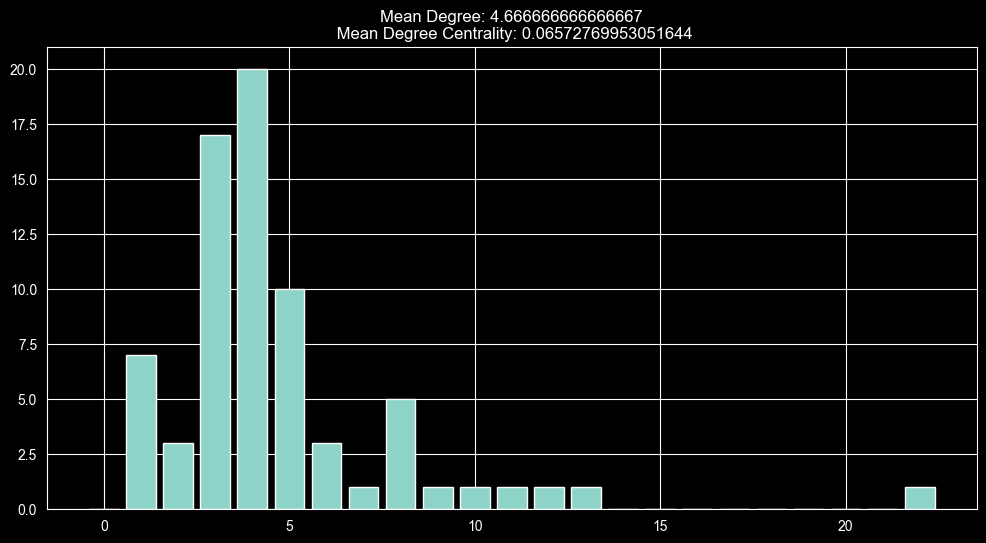

In [19]:
import matplotlib.pyplot as plt
import numpy as np

histo_degree = pd.DataFrame(nx.degree_histogram(nx_graph))
degree = dict(nx.degree(nx_graph))


mean_degree = np.mean(list(degree.values()))
mean_degree_centrality = np.mean(list(nx.degree_centrality(nx_graph).values()))

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(histo_degree.index.values,histo_degree[0])

plt.title("Mean Degree: {n1}\n Mean Degree Centrality: {n2}".format(n1=mean_degree,n2=mean_degree_centrality))
plt.show()

Another very useful measure is the clustering coefficient, which tells us how likely the nodes are to build clusters. This is a global measure, but can also be calculated for each node.


In [20]:
print("Clustering coefficient: {n}".format(n=nx.average_clustering(nx_graph)))


Clustering coefficient: 0.07673306631639965


### Exercise 3

Calculate and visualise the centrality of the music graph. Use a different measure than degree. For different measures you can refer to this online [documentation]{https://networkx.org/documentation/stable/reference/algorithms/centrality.html}. Choose wisely though, some measures require a long time to calculate (like betweenness or eigenvector centrality).

As a second step, take some time to explore the documentation of networkx. Is there something other you can calculate and learn about the graph?

In [24]:
# Calculate Closeness Centrality: how close a node is to all other nodes
closeness = nx.closeness_centrality(nx_music_graph)
closeness

{rdflib.term.URIRef('http://test.org/myonto.owl#5KF3zQP0cqLklYnF6riogg'): 1.3954397030504313e-05,
 rdflib.term.Literal('Sunday Morning Coming Down - Live'): 1.860586270733908e-05,
 rdflib.term.URIRef('http://test.org/myonto.owl#33vOmVmYIgn4QGUc0ooNio'): 1.3954397030504313e-05,
 rdflib.term.Literal('She Took You For A Ride'): 1.860586270733908e-05,
 rdflib.term.URIRef('http://test.org/myonto.owl#5BB0Jzw60KyfSTyjJqtely'): 1.3954397030504313e-05,
 rdflib.term.Literal('Na Na Na (Na Na Na Na Na Na Na Na Na)'): 1.860586270733908e-05,
 rdflib.term.URIRef('http://test.org/myonto.owl#1MvPNNN7sAoBDlvPD5KccG'): 1.3954397030504313e-05,
 rdflib.term.URIRef('http://test.org/myonto.owl#Song'): 0.3003473387223519,
 rdflib.term.URIRef('http://test.org/myonto.owl#5lZZmityu9TAjNvSY6GLhR'): 1.3954397030504313e-05,
 rdflib.term.Literal('Zack And Codeine'): 1.860586270733908e-05,
 rdflib.term.URIRef('http://test.org/myonto.owl#0weAUscowxeqDtpCgtbpgp'): 1.3954397030504313e-05,
 rdflib.term.URIRef('http://tes

In [26]:
# Check if the graph is directed:
nx.is_directed(nx_music_graph)

# Calculate page rank, which is most meaningful on directed graph
pagerank = nx.pagerank(nx_music_graph)
pagerank

{rdflib.term.URIRef('http://test.org/myonto.owl#5KF3zQP0cqLklYnF6riogg'): 9.145372451237479e-06,
 rdflib.term.Literal('Sunday Morning Coming Down - Live'): 1.2446908172868314e-05,
 rdflib.term.URIRef('http://test.org/myonto.owl#33vOmVmYIgn4QGUc0ooNio'): 9.394472583747694e-06,
 rdflib.term.Literal('She Took You For A Ride'): 1.2556608705244395e-05,
 rdflib.term.URIRef('http://test.org/myonto.owl#5BB0Jzw60KyfSTyjJqtely'): 9.447312005795316e-06,
 rdflib.term.Literal('Na Na Na (Na Na Na Na Na Na Na Na Na)'): 1.2579878515142353e-05,
 rdflib.term.URIRef('http://test.org/myonto.owl#1MvPNNN7sAoBDlvPD5KccG'): 8.874421429910578e-06,
 rdflib.term.URIRef('http://test.org/myonto.owl#Song'): 0.0777441218825102,
 rdflib.term.URIRef('http://test.org/myonto.owl#5lZZmityu9TAjNvSY6GLhR'): 9.145372451237479e-06,
 rdflib.term.Literal('Zack And Codeine'): 1.2446908172868314e-05,
 rdflib.term.URIRef('http://test.org/myonto.owl#0weAUscowxeqDtpCgtbpgp'): 9.447312005795316e-06,
 rdflib.term.URIRef('http://test.

From documentation:
- Closeness asks: how short are my paths to everyone else? A node is central if it can quickly reach all other nodes. It's purely based on graph distance.
- PageRank asks: how many important nodes point to me? A node is central if it receives links from other highly-ranked nodes. It's based on the link/connection structure, originally designed for directed graphs.

## 4. Visualizing your graph

With networkx you can easily visualise your ontology/graph, no matter if they include blank nodes or not. The visualisations are powered by matplotlib. We will use here the first ontology, which also has blank nodes, but is much simpler to visualise.

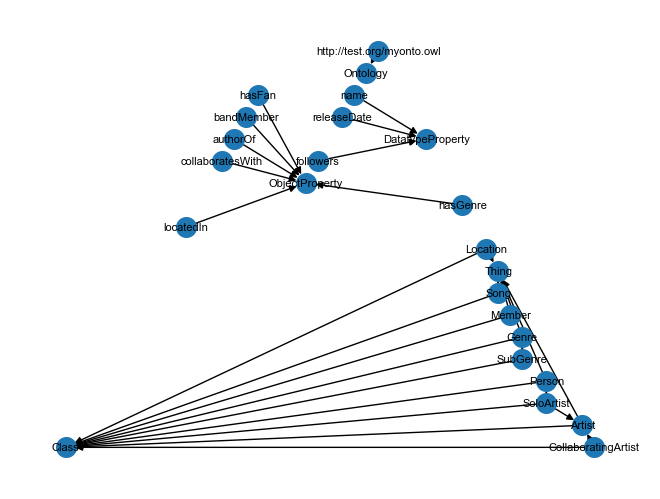

In [28]:
# list(nx_graph.nodes())

music_ontology = rdflib.Graph()
music_ontology.parse("data/music_onto_simple.rdf")
nx_graph = rdflib_to_networkx_digraph(music_ontology)

mapping = pd.DataFrame(nx_graph.nodes())
mapping['new_names'] = mapping[0].str.split("#",n=1,expand=False)
mapping['label'] = 'NA'
# print(mapping)
mapping_copy = mapping.copy()

for ind, m in mapping_copy.iterrows():
    l = len(m['new_names'])
    names = m['new_names']
    mapping.loc[ind,'label'] = names[l-1]

map_dict = dict(zip(mapping[0],mapping['label']))

# print(mapping)
nx_graph_nl = nx.relabel_nodes(nx_graph,map_dict,copy=True)


nx.draw_planar(nx_graph_nl,
                 with_labels=True,
                node_size=200, font_size=8 )
# plt.draw()

### Exercise 4

Try to visualise the Hybrid Intelligence ontology below. Don't shy away from looking for and trying other approaches to visualise an ontology, giving nodes different colours, or varying thickness/colour of the edges based on the type of relation.

In [31]:
# Load the ontology
hi_onto = rdflib.Graph()
hi_onto.parse("data/hi_ontology.ttl", format="turtle")
hi_onto_graph = rdflib_to_networkx_digraph(hi_onto)

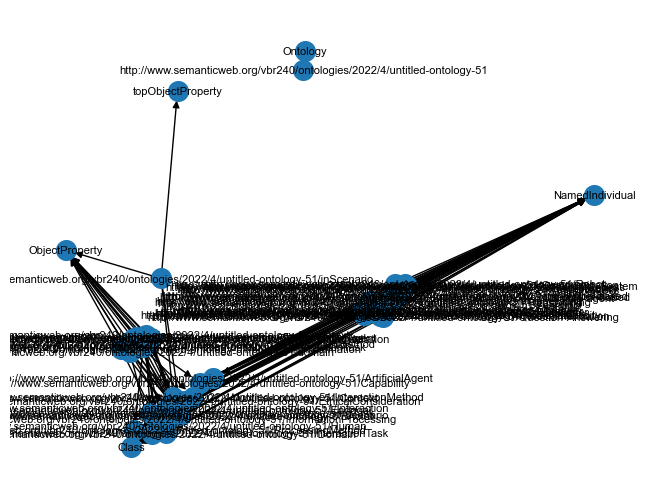

In [51]:
mapping = pd.DataFrame(hi_onto_graph.nodes())
mapping['new_names'] = mapping[0].str.split("#",n=1,expand=False)
mapping['label'] = 'NA'
# print(mapping)
mapping_copy = mapping.copy()

for ind, m in mapping_copy.iterrows():
    l = len(m['new_names'])
    names = m['new_names']
    mapping.loc[ind,'label'] = names[l-1]

map_dict = dict(zip(mapping[0],mapping['label']))

# print(mapping)
nx_graph_nl = nx.relabel_nodes(hi_onto_graph,map_dict,copy=True)

# Graph is not planar, edges cross
nx.draw_spring(nx_graph_nl, with_labels=True, node_size=200, font_size=8)

# plt.draw()

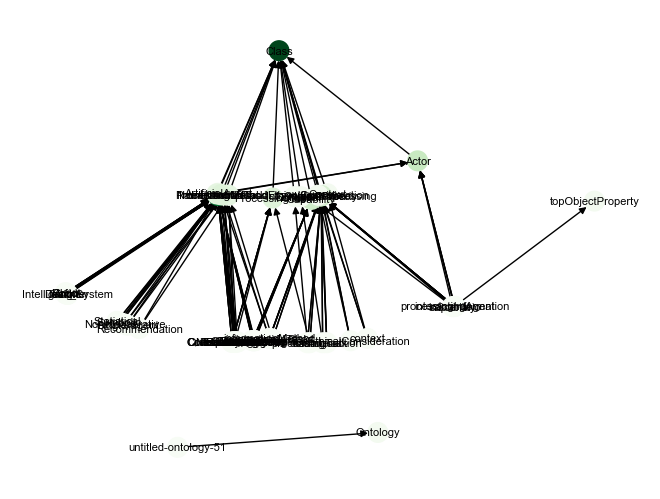

In [85]:
# Change the mapping of the labels
mapping = pd.DataFrame(hi_onto_graph.nodes())
mapping['new_names'] = mapping[0].apply(
    lambda x: str(x).split("#")[-1] if "#" in str(x) else str(x).split("/")[-1]
)

# Use a dictionary to use the new label names directly
map_dict = dict(zip(mapping[0], mapping['new_names']))

# print(mapping[['new_names']].head(20))

nx_graph_nl = nx.relabel_nodes(hi_onto_graph, map_dict, copy=True)

# Graph is not planar (edges cross)
# Show centrality in the graph. More central nodes are darker
centrality = nx.closeness_centrality(nx_graph_nl)
nx.draw(nx_graph_nl, pos=nx.kamada_kawai_layout(nx_graph_nl),
        with_labels=True, node_size=200, font_size=8,
        node_color=list(centrality.values()), cmap=plt.cm.Greens)

## 5. Clustering

NetworkX already comes with some clustering algorithms. We will try the one introduced in the theory part of the class, Louvain clustering algorithm.

In [54]:
import networkx.algorithms.community as nx_comm

communities = nx_comm.louvain_communities(nx_graph,resolution=1)
print(1,len(communities),nx.number_of_nodes(nx_graph))


1 5 24


Now we can visualise the graph and the communities within it. Alternatively you can also visualise a community as an example alone. (WARNING: this might take a while...)


/Users/kim/Desktop/P4/Knowledge Graphs and Semantic Technologies/TutorialNotebooks/KGST.venv/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:437: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


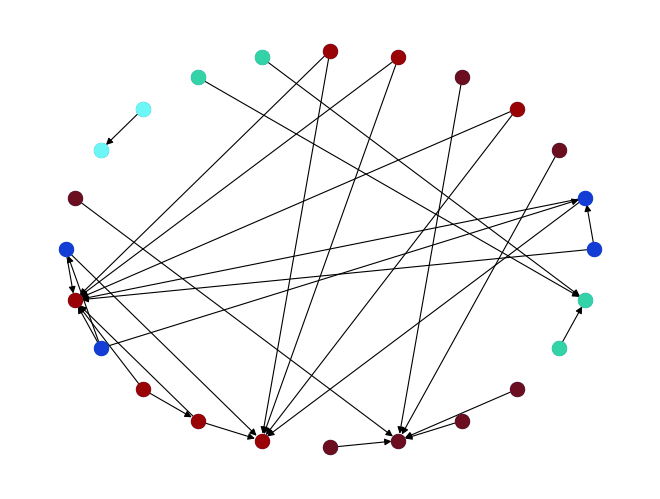

In [55]:
pos = nx.shell_layout(nx_graph)


nx.draw(nx_graph, pos, edge_color='k',font_weight='light',
        node_size= 100, width= 0.8)
for com in communities:
    nx.draw_networkx_nodes(nx_graph,
                           pos,
                           nodelist=com,
                           node_color=np.random.rand(3,),
                           node_size=100)
plt.show()

If clustering is successful and helpful is very dependent on your graph. It is beneficial to remove the information from your graph that is not helpful for the clustering, like the T-box of your ontology, as this "pollutes" the graph. The clustering algorithm is not made for knowledge graphs but rather for mathematical graphs, hence less semantics is better.

In the case above, the graph is not dense enough to produce meaningful clusters, which is why there are 38706 clusters.

### Exercise 5

Try to cluster your own graph. You might have to create a mathematical graph first, rather than just converting your knowledge graph, as that will lead to better and more insightful results.

In [57]:
# Use Louvain clustering algorithm on the full graph
communities = nx_comm.louvain_communities(hi_onto_graph,resolution=1)
print(1,len(communities),nx.number_of_nodes(hi_onto_graph))

1 9 62


/Users/kim/Desktop/P4/Knowledge Graphs and Semantic Technologies/TutorialNotebooks/KGST.venv/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:437: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


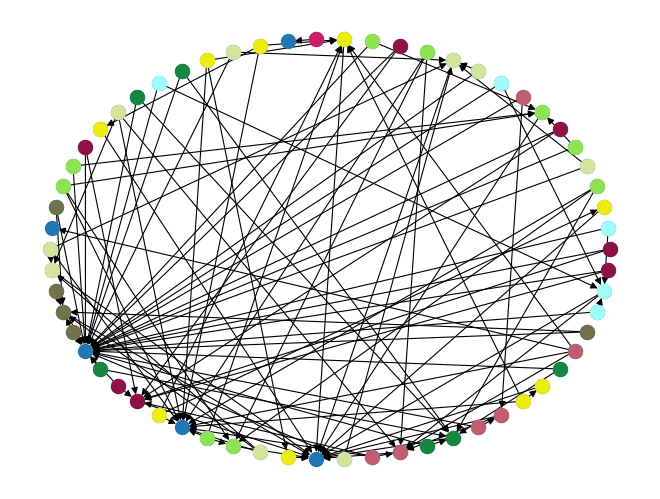

In [73]:
# Draw the clustering graph
pos = nx.shell_layout(hi_onto_graph)

nx.draw(hi_onto_graph, pos, edge_color='k',font_weight='light',
        node_size= 100, width= 0.8, margins=0.02)
for com in communities:
    nx.draw_networkx_nodes(hi_onto_graph,
                           pos,
                           nodelist=com,
                           node_color=np.random.rand(3,),
                           node_size=100)
plt.show()

In [77]:
# Remove T-box noise for better clustering
"""
OWL/RDF metadata nodes like owl:Class, rdf:type, NamedIndividual etc. are connected to almost every node in the ontology.
These can be removed to avoid unnecessary connections.
Removing them lets the algorithm see the actual relationships between the domain concept
"""
nodes_to_remove = [n for n in hi_onto_graph.nodes() if any(
str(n).startswith(prefix) for prefix in
    ['http://www.w3.org/2002/07/owl', 'http://www.w3.org/1999/02/22-rdf-syntax-ns']
)]

hi_onto_filtered = hi_onto_graph.copy()
hi_onto_filtered.remove_nodes_from(nodes_to_remove)

communities = nx_comm.louvain_communities(hi_onto_filtered, resolution=1)
print(len(communities), nx.number_of_nodes(hi_onto_filtered))

9 57


/Users/kim/Desktop/P4/Knowledge Graphs and Semantic Technologies/TutorialNotebooks/KGST.venv/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:437: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


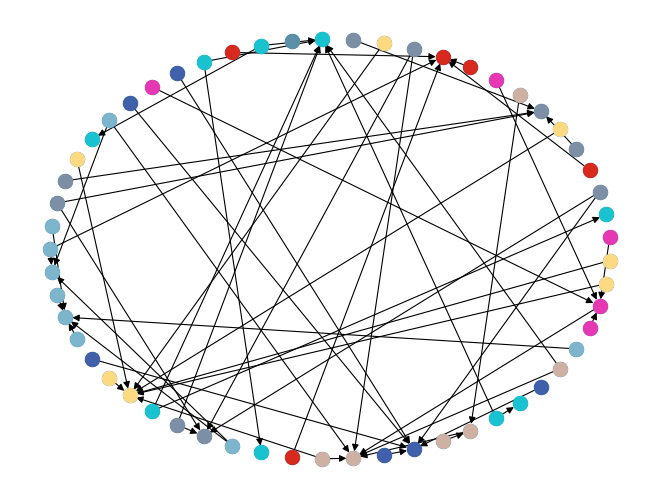

In [78]:
# Draw the clustering graph again
pos = nx.shell_layout(hi_onto_filtered)

nx.draw(hi_onto_filtered, pos, edge_color='k',font_weight='light',
        node_size= 100, width= 0.8, margins=0.02)
for com in communities:
    nx.draw_networkx_nodes(hi_onto_filtered,
                           pos,
                           nodelist=com,
                           node_color=np.random.rand(3,),
                           node_size=100)
plt.show()